<a href="https://colab.research.google.com/github/o-semenkova/ml_home_tasks/blob/main/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
from process_bank_churn import preprocess_data, evaluate_model_from_proba

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [5]:
raw_df = pd.read_csv("train.csv")
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [6]:
input_cols = list(raw_df.columns)[1:-1]
target_col = "Exited"
test_size = 0.2
RANDOM_STATE = 14

In [7]:
train_df, val_df = split_train_val(raw_df, target_col, test_size, RANDOM_STATE);

In [8]:
train_inputs, train_targets = separate_inputs_targets(train_df,input_cols, target_col)

In [9]:
val_inputs, val_targets = separate_inputs_targets(val_df,input_cols, target_col)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [10]:
cat_features = train_df.select_dtypes(include='object').columns

In [11]:
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [12]:
! pip freeze | grep xgboost

xgboost==3.1.3


In [13]:
import xgboost as xgb
from xgboost import XGBClassifier

In [14]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda'
)

In [15]:
xgb_clf.fit(train_inputs, train_targets)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:59:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [19:59:32] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


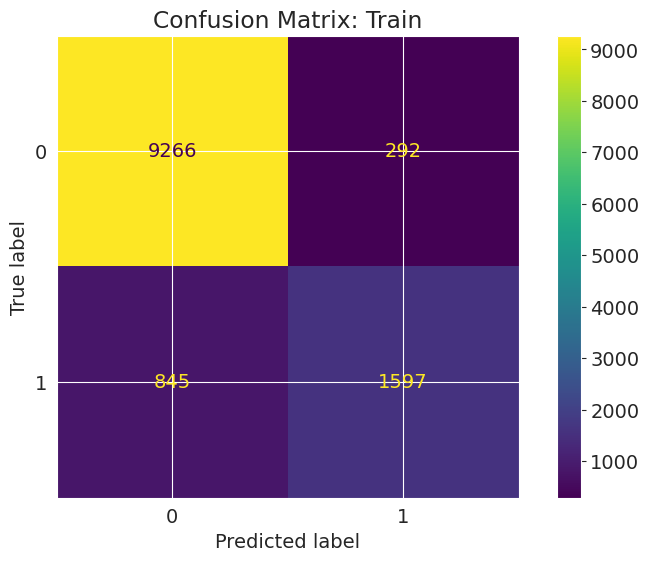

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


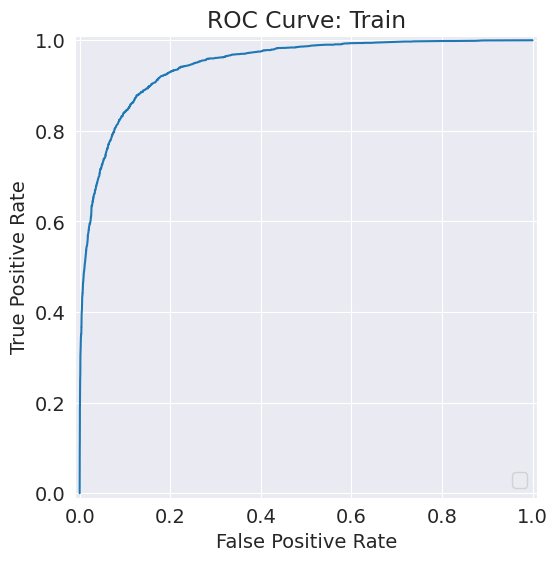

📊 Train — AUROC: 0.946, F1 Score (threshold=0.5): 0.737


In [16]:
train_probs = xgb_clf.predict_proba(train_inputs)[:, 1]
evaluate_model_from_proba(train_targets, train_probs, 'Train')

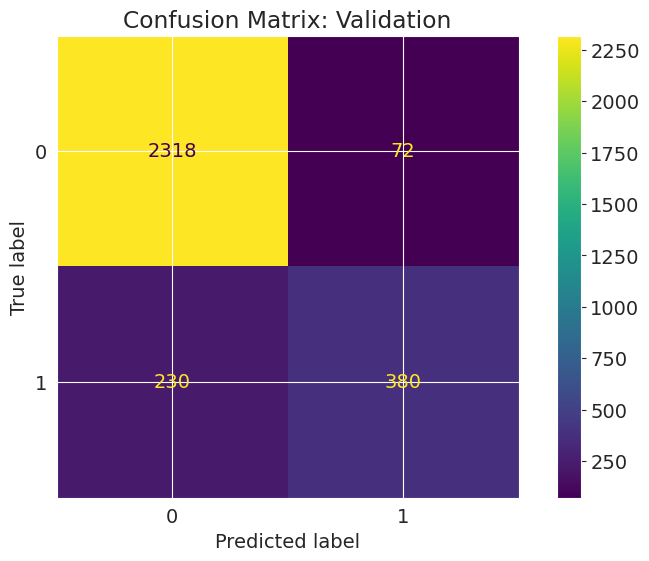

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


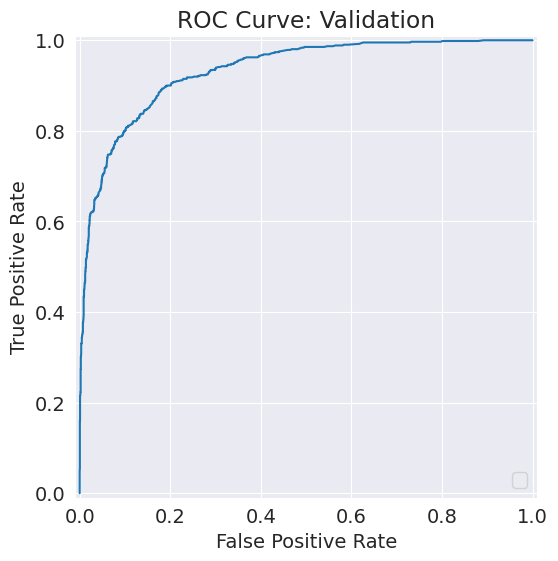

📊 Validation — AUROC: 0.933, F1 Score (threshold=0.5): 0.716


In [17]:
val_probs = xgb_clf.predict_proba(val_inputs)[:, 1]
evaluate_model_from_proba(val_targets, val_probs, 'Validation')

**Виходячи з показників AUROC, бачимо що присутнє невелике перенавчання (показник на train більше чим на val), але в загальному плані модель стала значно кращою в порівнянні з минулим експериментом: тоді AUROC був 0.908, а зараз 0.933**

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [18]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [19]:
from sklearn.metrics import roc_auc_score

In [20]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=20
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    val_probs = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, val_probs)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [21]:
# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
)

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [19:59:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:00<00:07,  2.47trial/s, best loss: -0.9363323959119282]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [19:59:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [19:59:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 15%|█▌        | 3/20 [00:01<00:07,  2.40trial/s, best loss: -0.9363323959119282]

...

 85%|████████▌ | 17/20 [00:07<00:01,  2.49trial/s, best loss: -0.9363323959119282]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [19:59:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 95%|█████████▌| 19/20 [00:07<00:00,  2.85trial/s, best loss: -0.9363323959119282]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [19:59:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [19:59:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:08<00:00,  2.42trial/s, best loss: -0.9363323959119282]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.5654787635349456), 'gamma': np.float64(0.03875854331172185), 'learning_rate': np.float64(0.25044766126207774), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 300, 'reg_alpha': np.float64(0.642463981594055), 'reg_lambda': np.float64(0.5681025311839041), 'subsample': np.float64(0.8334247400255366)}


In [22]:
final_clf.fit(train_inputs, train_targets)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:59:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.5654787635349456), device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.03875854331172185), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.25044766126207774), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

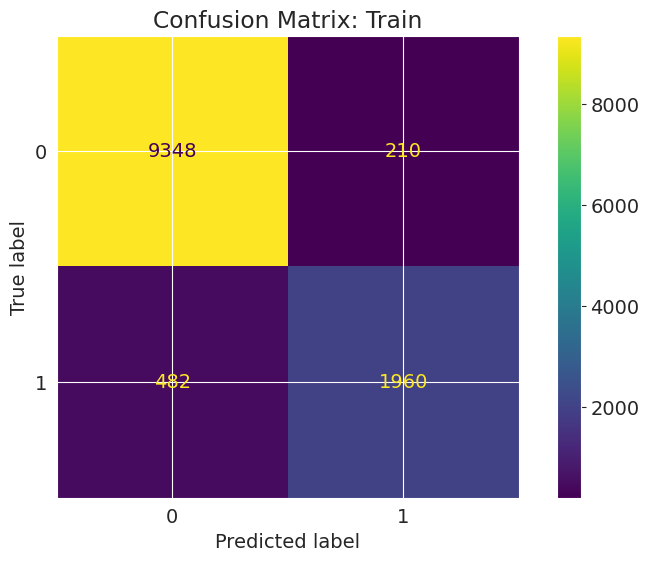

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


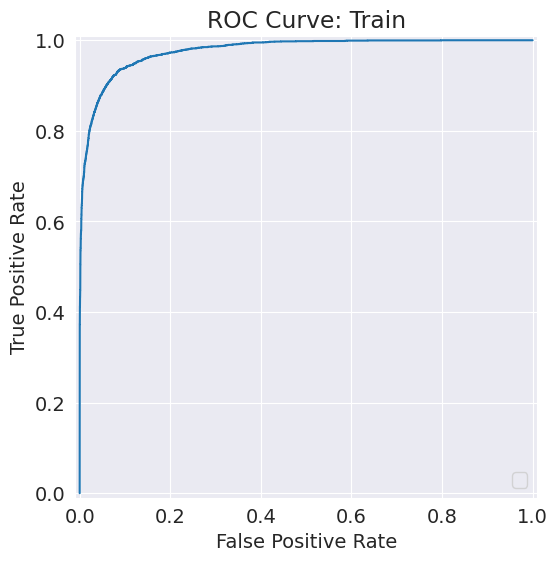

📊 Train — AUROC: 0.977, F1 Score (threshold=0.5): 0.850


In [23]:
train_probs = final_clf.predict_proba(train_inputs)[:, 1]
evaluate_model_from_proba(train_targets, train_probs, 'Train')

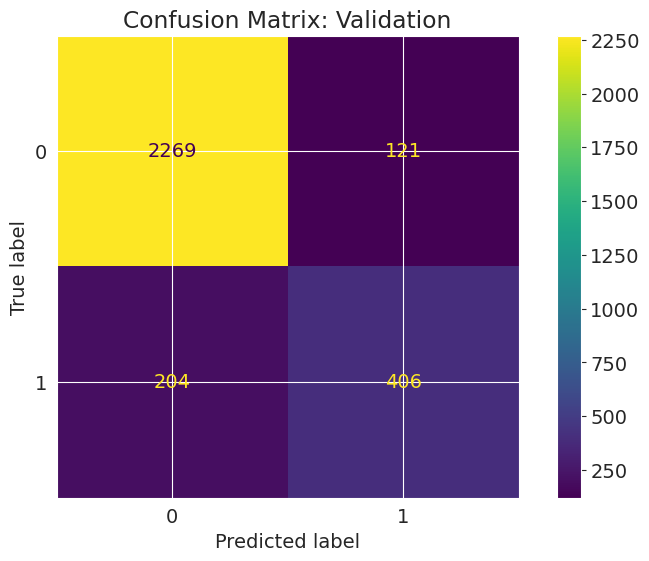

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


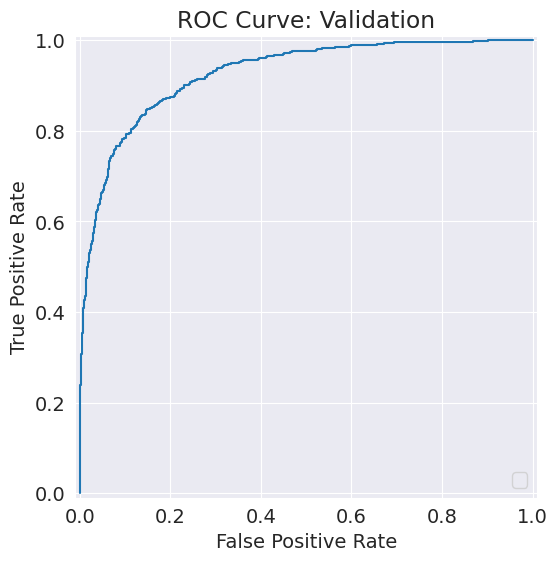

📊 Validation — AUROC: 0.926, F1 Score (threshold=0.5): 0.714


In [24]:
val_probs = final_clf.predict_proba(val_inputs)[:, 1]
evaluate_model_from_proba(val_targets, val_probs, 'Validation')

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [25]:
%%bash
set -e
# pip uninstall -y lightgbm || true

In [26]:
# %%bash
# sudo apt-get update
# sudo apt-get install -y build-essential cmake git libboost-dev libboost-system-dev \
#     libboost-filesystem-dev ocl-icd-libopencl1 clinfo nvidia-opencl-dev opencl-headers

In [27]:
# %%bash
# set -e

# cd /content
# rm -rf LightGBM

# git clone --recursive https://github.com/microsoft/LightGBM
# cd LightGBM

# # Видаляємо конфліктні LICENSE файли наперед
# rm -f ./lightgbm-python/LICENSE ./python-package/LICENSE 2>/dev/null || true

# # build-python.sh САМА створить build директорію і передасть всі параметри в cmake
# export CMAKE_BUILD_PARALLEL_LEVEL=2

# # Ключовий момент: передати --cuda в build-python.sh
# sh ./build-python.sh install --cuda 2>&1 | tee /content/lgbm_cuda_build.log

In [28]:
import numpy as np
import lightgbm as lgb

X = np.random.rand(4000, 30)
y = (X[:,0] + X[:,1] > 1).astype(int)
d = lgb.Dataset(X, label=y)

params = {"objective":"binary", "device_type":"cuda", "verbosity": 1}
lgb.train(params, d, num_boost_round=20)
print("OK: CUDA works")


[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Info] Number of positive: 2008, number of negative: 1992
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502000 -> initscore=0.008000
[LightGBM] [Info] Start training from score 0.008000
OK: CUDA works


In [29]:
import pandas as pd
import numpy as np

X_train_df = train_inputs.copy()
X_val_df   = val_inputs.copy()

# знайти всі нечислові колонки (object, string, category, bool тощо)
non_num_cols = X_train_df.columns[~X_train_df.dtypes.apply(lambda t: pd.api.types.is_numeric_dtype(t))].tolist()
print("Non-numeric columns:", non_num_cols)

for c in non_num_cols:
    # робимо спільні категорії на train+val, щоб коди збігались
    tr = X_train_df[c].astype("string").fillna("NA")
    va = X_val_df[c].astype("string").fillna("NA")
    cats = pd.Index(pd.concat([tr, va], axis=0).unique())
    cat_type = pd.CategoricalDtype(categories=cats)

    X_train_df[c] = tr.astype(cat_type).cat.codes.astype(np.int32)
    X_val_df[c]   = va.astype(cat_type).cat.codes.astype(np.int32)

# контроль: чи лишились строки?
left_obj = X_train_df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Still string/object columns:", left_obj)

# тепер можна в float32
Xtr = X_train_df.to_numpy(dtype=np.float32, copy=True)
Xva = X_val_df.to_numpy(dtype=np.float32, copy=True)

ytr = np.asarray(train_targets).ravel()
yva = np.asarray(val_targets).ravel()

print("Xtr dtype:", Xtr.dtype, "shape:", Xtr.shape)

Non-numeric columns: ['Surname', 'Geography', 'Gender']
Still string/object columns: []
Xtr dtype: float32 shape: (12000, 12)


In [30]:
# cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]

In [31]:
# lgb_clf = lgb.LGBMClassifier(
#     max_depth=3,
#     n_estimators=50,
#     learning_rate=0.1,
#     device='cuda',
#     max_bin=63,
#     num_gpu_threads=256,
#     gpu_use_dp=False
#     # cat_feature - немає такого параметра в LGBMClassifier
#     # використовуй categorical_feature замість cat_feature
#     # але краще передавати при fit()
# )

# lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

In [32]:
# train_probs = lgb_clf.predict_proba(train_inputs)[:, 1]
# evaluate_model_from_proba(train_targets, train_probs, 'Train')

In [33]:
# val_probs = lgb_clf.predict_proba(val_inputs)[:, 1]
# evaluate_model_from_proba(val_targets, val_probs, 'Validation')

**LightGBM без тюнингу дав нам такий же результат як XGBoost без тюнингу**

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [34]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        num_leaves=int(params["num_leaves"]),
        min_child_weight=float(params["min_child_weight"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        reg_alpha=float(params["reg_alpha"]),
        reg_lambda=float(params["reg_lambda"]),
        min_split_gain=float(params["min_split_gain"]),
        device_type="cuda",
        max_bin=127,
        gpu_use_dp=False,
        verbosity=-1,
    )
    clf.fit(
        Xtr, ytr,
        eval_X=Xva,
        eval_y=yva,
        callbacks=[lgb.log_evaluation(period=0)],
    )
    val_probs = clf.predict_proba(Xva)[:, 1]
    auc = roc_auc_score(yva, val_probs)
    return {"loss": -auc, "status": STATUS_OK}



# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

In [35]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

best["n_estimators"] = int(best["n_estimators"])
best["max_depth"] = int(best["max_depth"])
best["num_leaves"] = int(best["num_leaves"])
best["min_child_weight"] = float(best["min_child_weight"])

final_clf = lgb.LGBMClassifier(
    n_estimators=best["n_estimators"],
    learning_rate=float(best["learning_rate"]),
    max_depth=best["max_depth"],
    num_leaves=best["num_leaves"],
    min_child_weight=float(best["min_child_weight"]),
    subsample=float(best["subsample"]),
    colsample_bytree=float(best["colsample_bytree"]),
    reg_alpha=float(best["reg_alpha"]),
    reg_lambda=float(best["reg_lambda"]),
    min_split_gain=float(best["min_split_gain"]),
    device_type="cuda",
    max_bin=127,
    gpu_use_dp=False,
    verbosity=-1,
)

final_clf.fit(
    Xtr, ytr,
    eval_X=Xva,
    eval_y=yva,
    callbacks=[lgb.log_evaluation(period=50)],
)

 10%|█         | 1/10 [00:02<00:24,  2.75s/trial, best loss: -0.9243089375128609]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 20%|██        | 2/10 [00:04<00:17,  2.23s/trial, best loss: -0.9303889155634818]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 30%|███       | 3/10 [00:06<00:15,  2.15s/trial, best loss: -0.9303889155634818]

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



100%|██████████| 10/10 [00:23<00:00,  2.31s/trial, best loss: -0.9323842513203923]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(




[50]	valid_0's binary_logloss: 0.351815
[100]	valid_0's binary_logloss: 0.299145
[150]	valid_0's binary_logloss: 0.274232
[200]	valid_0's binary_logloss: 0.26247
[250]	valid_0's binary_logloss: 0.255716
[300]	valid_0's binary_logloss: 0.252182
[350]	valid_0's binary_logloss: 0.250708


LGBMClassifier(colsample_bytree=0.500906219051459, device_type='cuda',
               gpu_use_dp=False, learning_rate=0.017392000135372482,
               max_bin=127, max_depth=7, min_child_weight=6.0,
               min_split_gain=0.09949210779572634, n_estimators=350,
               num_leaves=116, reg_alpha=0.994050820835165,
               reg_lambda=0.16603109477156475, subsample=0.7142411661401169,
               verbosity=-1)

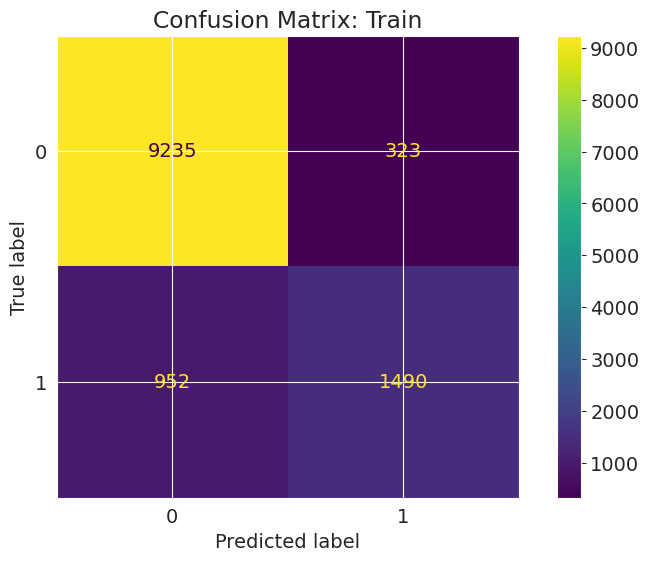

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


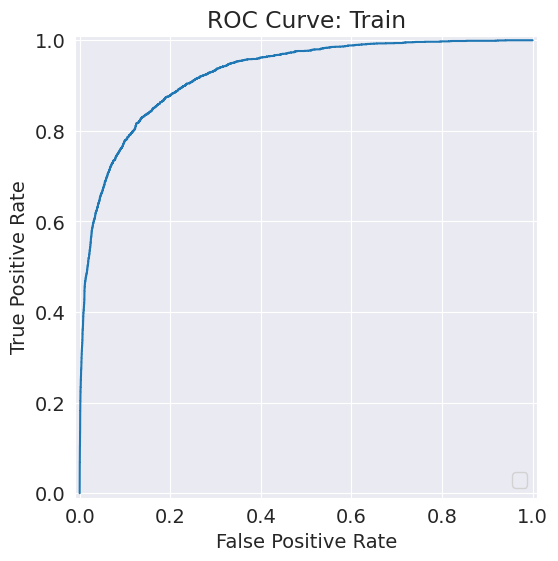

📊 Train — AUROC: 0.926, F1 Score (threshold=0.5): 0.700


In [36]:
train_probs = final_clf.predict_proba(train_inputs)[:, 1]
evaluate_model_from_proba(train_targets, train_probs, 'Train')

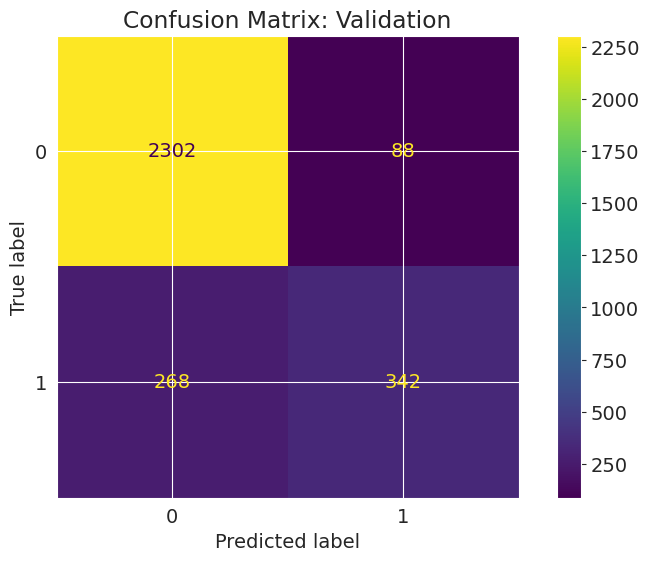

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


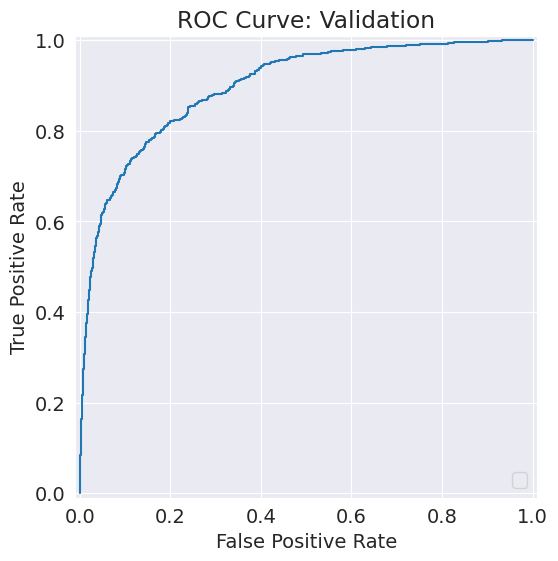

📊 Validation — AUROC: 0.898, F1 Score (threshold=0.5): 0.658


In [37]:
val_probs = final_clf.predict_proba(val_inputs)[:, 1]
evaluate_model_from_proba(val_targets, val_probs, 'Validation')

**Як бачимо, LightGBM показує гірші результати ніж XGBoost (0.898 проти 0.933), тож обираємо XGBoost з тюнингом**